In [ ]:
!pip install torchinfo -q

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from tqdm.auto import tqdm
from pathlib import Path
import matplotlib.pyplot as plt

from tokenizers import Tokenizer
from tokenizers.models import BPE
import tokenizers.pre_tokenizers as pre_tokenizers
import tokenizers.decoders as decoders
from tokenizers.trainers import BpeTrainer

from torchinfo import summary
torch.manual_seed(1357)

In [ ]:
pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammedmohsen0404/shakespeare-txt")

print("Path to dataset files:", path)

100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 2.32M/2.32M [00:01<00:00, 1.39MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mohammedmohsen0404/shakespeare-txt/versions/1


In [ ]:
import os

with open(os.path.join(path, 'shakespeare.txt'), 'r', encoding='utf-8') as f:
    data = f.read()

In [ ]:
data[:100]

'\ufeff1603\n\nALLS WELL THAT ENDS WELL\n\nby William Shakespeare\n\nDramatis Personae\n\n  KING OF FRANCE\n  THE D'

In [ ]:
tokenizer_path = Path('./tokenizer/')
if not tokenizer_path.exists():
    tokenizer_path.mkdir()
tokenizer = Tokenizer(BPE())
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
import tokenizers.processors as processors
tokenizer.post_processor = processors.ByteLevel(trim_offsets=False)
tokenizer.decoder = decoders.ByteLevel()
trainer = BpeTrainer(special_tokens=['<|endoftext|>'], min_frequency=2)

tokenizer.train([str(Path(path) / 'shakespeare.txt')], trainer)
tokenizer.save(str(tokenizer_path / 'shakespeare.json'))

In [ ]:
@dataclass
class Config:

    block_size = 256 # context-length
    batch_size = 64 # mini-batch size

    vocab_size = tokenizer.get_vocab_size()

    train_size = 0.9

    n_embed = 384
    n_heads = 6
    head_size = n_embed // n_heads # computes to 384/6=64

    n_layers = 3

    train_iters = 5000 # no. of batches to train on
    val_iters = 500 # no. of batches to validate on every eval_intervals
    eval_interval = 1000 # validate after every eval_interval iterations while training

    lr = 5e-4

    attn_dropout = 0.2
    block_dropout = 0.2

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

Config.device, Config.vocab_size

('cuda', 30000)

In [ ]:
class ShakespeareDataset:
    def __init__(self, Config, is_test=False) -> None:
        self.file_path = Path(path) / 'shakespeare.txt'
        self.tokenizer_path = Path('/content/tokenizer/shakespeare.json')
        with open(self.file_path,'r',encoding='utf-8') as f:
            self.data = f.read()
        self.tokenizer = Tokenizer.from_file(str(self.tokenizer_path))

        self.full_data = torch.tensor(self.tokenizer.encode(self.data).ids, dtype=torch.long)

        self.is_test = is_test
        if self.is_test:
            self.data = self.full_data[int(Config.train_size*len(self.full_data)):]
        else:
            self.data = self.full_data[:int(Config.train_size*len(self.full_data))]

        self.block_size = Config.block_size
        self.batch_size = Config.batch_size

    def __len__(self) -> int:
        return len(self.data)

    def get_block_size(self) -> int:
        return self.block_size

    def get_vocab_size(self) -> int:
        return self.tokenizer.get_vocab_size()

    def __next__(self):
        ix = torch.randint(len(self.data) - self.block_size, (self.batch_size,))
        x = torch.stack([self.data[i:i+self.block_size] for i in ix])
        y = torch.stack([self.data[i+1:i+self.block_size+1] for i in ix])
        return x,y

In [ ]:
class AttentionHead(nn.Module):
    def __init__(self, Config):
        super().__init__()

        self.block_size = Config.block_size
        self.n_embed = Config.n_embed
        self.head_size = Config.head_size

        self.key = nn.Linear(self.n_embed, self.head_size, bias=False)
        self.query = nn.Linear(self.n_embed, self.head_size, bias=False)

        self.value = nn.Linear(self.n_embed, self.head_size, bias=False)

        self.register_buffer(
            'tril',
            torch.tril(torch.ones(self.block_size,self.block_size))
        )

        self.dropout = nn.Dropout(Config.attn_dropout)

    def forward(self, x):

        B,T,C = x.shape

        k = self.key(x)
        q = self.query(x)

        wei = q@k.transpose(-2,-1) * (C ** 0.5)
        wei = wei.masked_fill(self.tril[:T,:T]==0,float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        v = self.value(x)
        out = wei @ v

        return out

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, Config):
        super().__init__()
        self.n_heads = Config.n_heads
        self.head_size = Config.head_size

        self.heads = nn.ModuleList([AttentionHead(Config) for _ in range(self.n_heads)])

        self.projection = nn.Linear(Config.n_embed, Config.n_embed)

        self.dropout = nn.Dropout(Config.attn_dropout)

    def forward(self,x):
        x = torch.cat([h(x) for h in self.heads],dim=-1)
        x = self.projection(x)
        x = self.dropout(x)
        return x

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, Config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(Config.n_embed,Config.n_embed * 4),
            nn.ReLU(),
            nn.Linear(Config.n_embed * 4, Config.n_embed), # projection
            nn.Dropout(Config.block_dropout)
        )
    def forward(self,x):
        return self.net(x)

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, Config):
        super().__init__()
        self.attn = MultiHeadAttention(Config)
        self.ff = FeedForward(Config)
        self.ln1 = nn.LayerNorm(Config.n_embed)
        self.ln2 = nn.LayerNorm(Config.n_embed)

    def forward(self,x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))

        return x

In [ ]:
class ShakespeareGPT(nn.Module):
    def __init__(self,Config):
        super().__init__()

        self.n_embed = Config.n_embed
        self.block_size = Config.block_size

        self.token_embedding_table = nn.Embedding(Config.vocab_size,self.n_embed)
        self.pos_embedding_table = nn.Embedding(self.block_size, self.n_embed)

        self.blocks = nn.Sequential(
            *[TransformerBlock(Config)]*Config.n_layers,
            nn.LayerNorm(self.n_embed)
        )

        self.lm_head = nn.Linear(self.n_embed,Config.vocab_size)

    def forward(self,idx):

        B,T = idx.shape

        token_embs = self.token_embedding_table(idx)
        pos_embs = self.pos_embedding_table(torch.arange(T,device=Config.device))


        x = token_embs + pos_embs
        x = self.blocks(x)
        logits = self.lm_head(x)

        return logits


    def generate(self,idx,total):
        for _ in range(total):
            idx_cond = idx[:, -self.block_size:]
            logits= self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

In [ ]:
train_ds = ShakespeareDataset(Config)
val_ds = ShakespeareDataset(Config,is_test=True)

In [ ]:
lm = ShakespeareGPT(Config)
lm = lm.to(device=Config.device)

In [ ]:
summary(lm,input_size=(Config.batch_size, Config.block_size),dtypes=[torch.long],depth=5,)

Layer (type:depth-idx)                        Output Shape              Param #
ShakespeareGPT                                [64, 256, 30000]          --
â”œâ”€Embedding: 1-1                              [64, 256, 384]            11,520,000
â”œâ”€Embedding: 1-2                              [256, 384]                98,304
â”œâ”€Sequential: 1-3                             [64, 256, 384]            --
â”‚    â””â”€TransformerBlock: 2-1                  [64, 256, 384]            --
â”‚    â”‚    â””â”€LayerNorm: 3-1                    [64, 256, 384]            768
â”‚    â”‚    â””â”€MultiHeadAttention: 3-2           [64, 256, 384]            --
â”‚    â”‚    â”‚    â””â”€ModuleList: 4-9              --                        (recursive)
â”‚    â”‚    â”‚    â”‚    â””â”€AttentionHead: 5-1      [64, 256, 64]             73,728
â”‚    â”‚    â”‚    â”‚    â””â”€AttentionHead: 5-2      [64, 256, 64]             73,728
â”‚    â”‚    â”‚    â”‚    â””â”€AttentionHead: 5-3      [64, 256, 64] 

In [ ]:
optim = torch.optim.AdamW(lm.parameters(), lr=Config.lr)

In [ ]:
def loss_fn(logits, targets):
    B,T,C = logits.shape
    logits = logits.view(B*T, C)
    targets = targets.view(B*T)
    loss = F.cross_entropy(logits,targets)
    return loss

In [ ]:
@torch.no_grad()
def valid_N_iters():
    val_step_losses = []
    for batch in tqdm(range(Config.val_iters)):
        inputs, targets = next(val_ds)
        inputs, targets = inputs.to(device=Config.device), targets.to(device=Config.device)
        logits = lm(inputs)
        loss = loss_fn(logits,targets)
        val_step_losses.append(loss.item())

        del inputs, targets, loss, logits

    val_loss = torch.tensor(val_step_losses).mean()
    print(f'val loss: {val_loss}')
    return val_loss

In [ ]:
def train_N_iters():
    lm.train()
    train_step_losses = []
    val_losses = []
    for batch in tqdm(range(Config.train_iters)):
        optim.zero_grad()
        inputs, targets = next(train_ds)
        inputs, targets = inputs.to(device=Config.device), targets.to(device=Config.device)
        logits = lm(inputs)
        loss = loss_fn(logits,targets)
        loss.backward()
        optim.step()
        train_step_losses.append(loss.item())

        if batch%(Config.train_iters//10)==0 or batch==Config.train_iters-1:
            print(f"\n{'-'*50}\nbatch {batch} train step loss: {loss.item()}")
            print(f"train loss so far: {torch.tensor(train_step_losses).mean()}\n{'-'*50}\n")

        if batch%Config.eval_interval==0 or batch==Config.train_iters-1:
            lm.eval()
            val_loss = valid_N_iters()
            lm.train()
            val_losses.append(val_loss.item())

            del val_loss

        del inputs, targets, loss, logits

    return train_step_losses, val_losses

In [ ]:
def save_lm():
    state_dict = lm.state_dict()
    save_path = Path('./').resolve() / 'shakespeareGPT'
    save_path.mkdir(exist_ok=True)
    model_path = save_path / f'shakespeareGPT.pth'
    torch.save(state_dict, model_path)

In [ ]:
def train_lm():
    train_step_losses,val_losses = train_N_iters()
    save_lm()
    return train_step_losses,val_losses

In [ ]:
tsl,vl=train_lm()

  0%|          | 0/5000 [00:00<?, ?it/s]


--------------------------------------------------
batch 0 train step loss: 10.491122245788574
train loss so far: 10.491122245788574
--------------------------------------------------



  0%|          | 0/500 [00:00<?, ?it/s]

val loss: 9.961289405822754

--------------------------------------------------
batch 500 train step loss: 4.782591819763184
train loss so far: 5.249983310699463
--------------------------------------------------


--------------------------------------------------
batch 1000 train step loss: 4.484757423400879
train loss so far: 4.928828239440918
--------------------------------------------------



  0%|          | 0/500 [00:00<?, ?it/s]

...

val loss: 5.051901817321777

--------------------------------------------------
batch 3500 train step loss: 4.2008819580078125
train loss so far: 4.497686862945557
--------------------------------------------------


--------------------------------------------------
batch 4000 train step loss: 4.197686672210693
train loss so far: 4.464948654174805
--------------------------------------------------



  0%|          | 0/500 [00:00<?, ?it/s]

val loss: 5.03340482711792

--------------------------------------------------
batch 4500 train step loss: 4.2361297607421875
train loss so far: 4.440774440765381
--------------------------------------------------


--------------------------------------------------
batch 4999 train step loss: 4.253692150115967
train loss so far: 4.421132564544678
--------------------------------------------------



  0%|          | 0/500 [00:00<?, ?it/s]

val loss: 5.072146892547607


In [ ]:
tsl_mean = torch.tensor(tsl).mean()
print('Train Loss:',tsl_mean.item())

Train Loss: 4.421132564544678


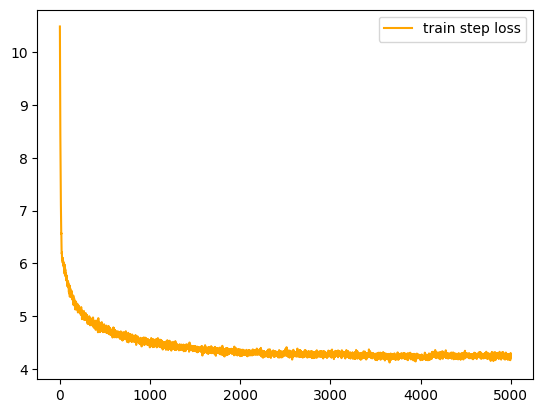

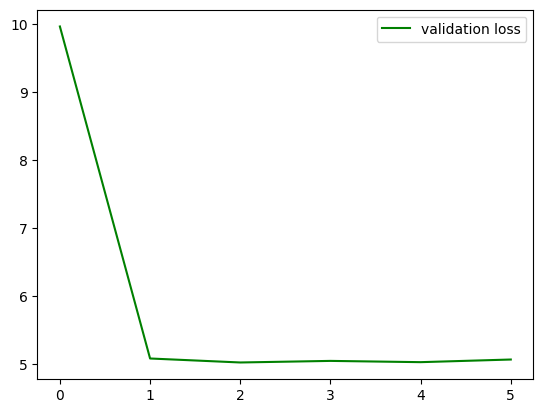

In [ ]:
plt.plot(tsl,label='train step loss',color='orange')
plt.legend()
plt.show()
plt.plot(vl,label='validation loss',color='green')
plt.legend()
plt.show()

In [ ]:
generated_texts = []
for length in [100,300,500,700,1000]:
    generated = lm.generate(
    torch.zeros((1,1),dtype=torch.long,device=Config.device)+61, # initial context 61 (i believe its \n)
    total=length
)
    generated = tokenizer.decode(generated[0].cpu().numpy())
    text=f'generated ({length} tokens)\n{"="*50}\n{generated}\n{"="*50}\n\n'
    generated_texts.append(text)
    print(text)

generated (100 tokens)
h for my little.
Enter SILENCE in the conqueror, and tutor fever a billows hour. And kept the world. Ah, which, in any, lady going make not bear your veryTeach may take with the first with fear thy father,
  ULYSSES. Nay, a dissolute 'twould make thy speed; you did but even so,
  GLOUCESTER. Thou liest even the matter, for help! Masters, sir! And if you and cannot brook'd save your city on women; thus and


generated (300 tokens)
homet of battle
    And so adieu with another dotes! What seem to
We stood myself. Whoever spoke bears;
    Celestial keep thee cruelly than elivia!
  SECOND OUTLAW. Go, and sway'd you, Page,
    And now makes harmful wits have discover the lands of justice of my labour from other part do yours, I other
    In women! as I desire why shall be infused you have grace as I will do Brutus to the sparks of your leave we were right enough!
    Which to you what in France, are to my good cheer tenour of this fortune;

    And seek for evermore u

In [ ]:
with open('generated.txt','w') as f:
    for text in generated_texts:
        f.write(text)